# Market Bias in Amazon Electronics Reviews

**Main deliverable notebook for CSCE 676.**

This project investigates whether product presentation, especially the gender attribute of product models, is associated with systematic differences in product ratings in the Market Bias Electronics dataset. The notebook is curated around the final project story: motivation, data, research questions, methods, results, and conclusions.


## Motivation

Online product reviews are often treated as direct signals of product quality, but ratings may also reflect presentation choices and market bias. In the Electronics portion of the Market Bias dataset, products include attributes such as category, brand, rating, and `model_attr`, which represents the gender presentation of the product model. This project asks whether those presentation attributes are merely descriptive or whether they relate to measurable rating differences.

I focus on the Electronics dataset because it is large enough to support meaningful pattern mining and statistical modeling, but still practical to analyze in Colab without distributed computing. The tradeoff is that the analysis has to manage sparse brands, missing values, and highly skewed ratings.


## Research Questions

**RQ1 — Pattern Mining:** Do certain combinations of product attributes and model gender frequently co-occur with high or low ratings?

**RQ2 — Clustering:** Do distinct clusters of products emerge based on product attributes and ratings, and do those clusters reflect systematic model-gender differences?

**RQ3 — Causal/Fairness Analysis:** Does model gender have a measurable relationship with product ratings after controlling for category and brand?

These questions align with the assignment guidance from the earlier checkpoints: RQ1 uses frequent itemset/association rule mining, RQ2 uses clustering, and RQ3 uses regression-based causal/fairness analysis as an external method.


## Setup and Data Loading

Place the dataset at `data/df_electronics.csv`, or run in Colab and update the Google Drive path if needed.


In [1]:
import sys
import warnings
import os

warnings.filterwarnings("ignore", category=DeprecationWarning)
os.environ["PYTHONWARNINGS"] = "ignore::DeprecationWarning"

class FilteredStderr:
    def __init__(self, original_stderr):
        self.original_stderr = original_stderr

    def write(self, message):
        blocked = [
            "datetime.datetime.utcnow() is deprecated",
            "jupyter_client/session.py"
        ]

        if any(text in message for text in blocked):
            return

        self.original_stderr.write(message)

    def flush(self):
        self.original_stderr.flush()

sys.stderr = FilteredStderr(sys.stderr)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Dataset path used by this repository.
DATA_PATH = Path("data/df_electronics.csv")

# If running in Colab and the data file is not in the repo, mount Google Drive
# and update DATA_PATH to the exact file location if needed.
if not DATA_PATH.exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        # Example fallback location. Change this if your Drive folder is different.
        DATA_PATH = Path("/content/drive/MyDrive/CSCE676 Project Data/df_electronics.csv")
    except Exception:
        pass

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. Place the file at data/df_electronics.csv "
        "or update DATA_PATH to the correct location."
    )

df_elec = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Electronics shape:", df_elec.shape)
import warnings
import os

# Hide Python deprecation warnings from notebook/Jupyter internals
warnings.simplefilter("ignore", DeprecationWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Also suppress warnings coming through Python warning environment behavior
os.environ["PYTHONWARNINGS"] = "ignore::DeprecationWarning"

Loaded: data/df_electronics.csv
Electronics shape: (1292954, 10)


## Data Preparation and Descriptive Summary

The analysis keeps the three model-gender groups used throughout the project: `Male`, `Female`, and `Female&Male`. Ratings are also converted into interpretable buckets for pattern mining. I use rating buckets rather than raw rating values because association rules are easier to interpret as high-, medium-, and low-rating outcomes.


In [3]:
import pandas as pd

# Copy and keep only relevant model groups
df = df_elec.copy()
df = df[df["model_attr"].isin(["Male", "Female", "Female&Male"])].copy()

# -----------------------------
# 1. Dataset size
# -----------------------------
n_reviews = len(df)
print(f"Amazon Electronics Dataset (~{n_reviews:,} reviews)")

# -----------------------------
# 2. Rating distribution
# -----------------------------
rating_counts = (
    df["rating"]
    .value_counts()
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="count")
)

rating_counts["percent"] = rating_counts["count"] / rating_counts["count"].sum()

print("\nRating Distribution:")
print(rating_counts)

# -----------------------------
# 3. Mean rating by model gender
# -----------------------------
mean_rating_by_gender = (
    df.groupby("model_attr")["rating"]
    .mean()
    .reindex(["Male", "Female", "Female&Male"])
    .reset_index(name="mean_rating")
)

print("\nMean Rating by Model Gender:")
print(mean_rating_by_gender)

# -----------------------------
# 4. 5-star rate by model gender
# -----------------------------
five_star_rate_by_gender = (
    df.assign(is_5_star=(df["rating"] == 5).astype(int))
    .groupby("model_attr")["is_5_star"]
    .mean()
    .reindex(["Male", "Female", "Female&Male"])
    .reset_index(name="five_star_rate")
)

print("\n5-Star Rate by Model Gender:")
print(five_star_rate_by_gender)

# -----------------------------
# 5. Optional: combined summary table
# -----------------------------
slide_summary = mean_rating_by_gender.merge(
    five_star_rate_by_gender,
    on="model_attr"
)

print("\nSlide Summary:")
print(slide_summary)

Amazon Electronics Dataset (~1,292,954 reviews)

Rating Distribution:
   rating   count   percent
0     1.0  143755  0.111183
1     2.0   78648  0.060828
2     3.0  100630  0.077830
3     4.0  214166  0.165641
4     5.0  755755  0.584518

Mean Rating by Model Gender:
    model_attr  mean_rating
0         Male     4.005925
1       Female     4.066153
2  Female&Male     4.084244

5-Star Rate by Model Gender:
    model_attr  five_star_rate
0         Male        0.561316
1       Female        0.594437
2  Female&Male        0.598121

Slide Summary:
    model_attr  mean_rating  five_star_rate
0         Male     4.005925        0.561316
1       Female     4.066153        0.594437
2  Female&Male     4.084244        0.598121


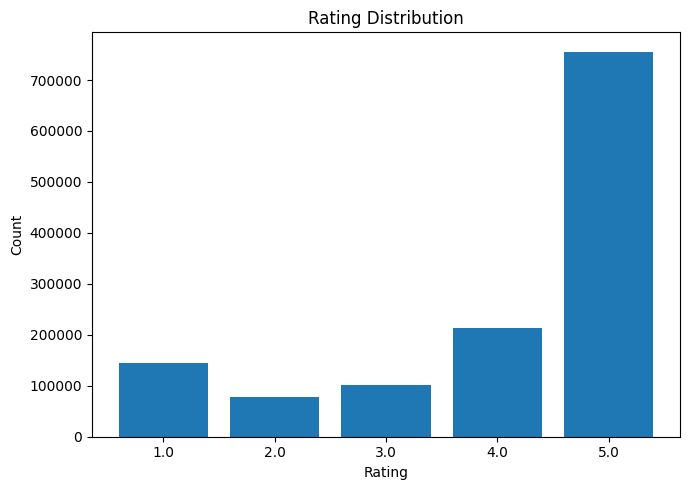

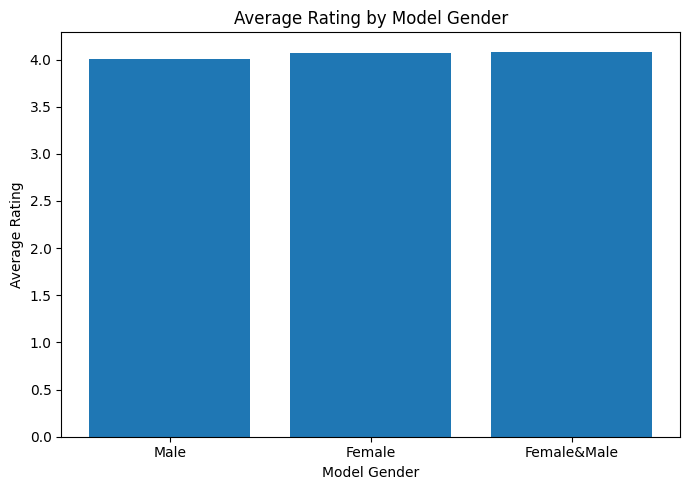

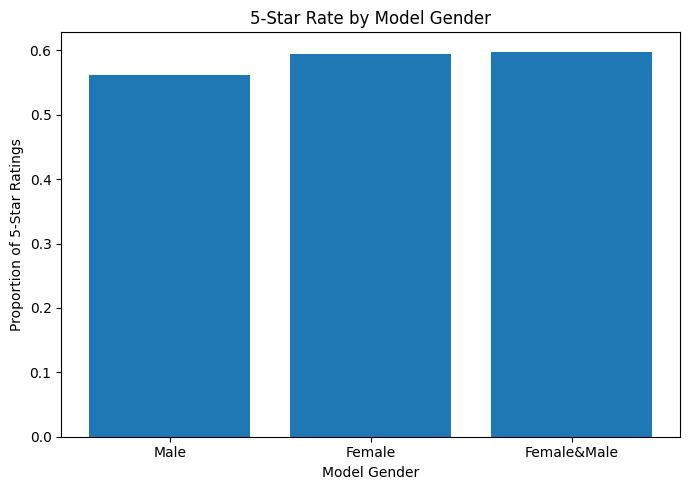

In [4]:
import matplotlib.pyplot as plt

# -----------------------------
# Graph 1: Rating distribution
# -----------------------------
plt.figure(figsize=(7,5))
plt.bar(rating_counts["rating"].astype(str), rating_counts["count"])
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# -----------------------------
# Graph 2: Mean rating by model gender
# -----------------------------
plt.figure(figsize=(7,5))
plt.bar(mean_rating_by_gender["model_attr"], mean_rating_by_gender["mean_rating"])
plt.title("Average Rating by Model Gender")
plt.xlabel("Model Gender")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

# -----------------------------
# Graph 3: 5-star rate by model gender
# -----------------------------
plt.figure(figsize=(7,5))
plt.bar(five_star_rate_by_gender["model_attr"], five_star_rate_by_gender["five_star_rate"])
plt.title("5-Star Rate by Model Gender")
plt.xlabel("Model Gender")
plt.ylabel("Proportion of 5-Star Ratings")
plt.tight_layout()
plt.show()

## RQ1: Association Rules and FP-Growth

For RQ1, I use FP-Growth because it is more scalable than a naive Apriori-style search on a dataset with many repeated transactions. To keep the rules readable and avoid brand sparsity, I restrict the pattern-mining table to the top brands. The goal is not to claim that gender alone determines ratings, but to see whether model gender appears inside attribute combinations that are associated with high or low rating outcomes.

The rating buckets are:
- `Low`: ratings 1–3
- `Medium`: rating 4
- `High`: rating 5


In [5]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

df_pm = df[["model_attr", "category", "brand", "rating"]].dropna().copy()

# Keep top brands so the rules are readable and not too sparse
top_brands = df_pm["brand"].value_counts().head(25).index
df_pm = df_pm[df_pm["brand"].isin(top_brands)].copy()

# Create rating buckets
df_pm["rating_label"] = pd.cut(
    df_pm["rating"],
    bins=[0, 3, 4, 5],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

print(df_pm["rating_label"].value_counts())
print(df_pm.shape)

rating_label
High      166452
Low        70070
Medium     49450
Name: count, dtype: int64
(285972, 5)


In [6]:
# Sample for speed if needed
sample_n = min(120000, len(df_pm))
df_pm_sample = df_pm.sample(n=sample_n, random_state=42).copy()

transactions = df_pm_sample[["model_attr", "category", "brand", "rating_label"]].astype(str).values.tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

print(df_trans.shape)
df_trans.head()

(120000, 41)


,Accessories & Supplies,Apple,Bose,Camera & Photo,Canon,Car Electronics & GPS,Computers & Accessories,EldHus,Etre Jeune,Female,...,Portable Audio & Video,Pyle,Samsung,Security & Surveillance,Sennheiser,Skullcandy,Sony,TaoTronics,Television & Video,Wearable Technology
0,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
1,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
freq_items = fpgrowth(
    df_trans,
    min_support=0.01,
    use_colnames=True
)

rules = association_rules(
    freq_items,
    metric="lift",
    min_threshold=1.0
)

# Keep only rules whose consequence is rating-related
rules_rating = rules[
    rules["consequents"].apply(lambda x: any(label in x for label in ["High", "Medium", "Low"]))
].copy()

rules_rating = rules_rating.sort_values(["lift", "confidence"], ascending=False)

print(rules_rating[["antecedents", "consequents", "support", "confidence", "lift"]].head(20))

                           antecedents  \
525                           (Garmin)   
523            (Car Electronics & GPS)   
1084                      (TaoTronics)   
1078         (TaoTronics, Female&Male)   
1081         (Female&Male, Home Audio)   
817           (Accessories & Supplies)   
815                   (Female, EldHus)   
1086                      (Home Audio)   
1071                      (TaoTronics)   
1073                      (Home Audio)   
813   (Accessories & Supplies, Female)   
390    (Male, Computers & Accessories)   
819                           (EldHus)   
1024                        (Fujifilm)   
395                         (Logitech)   
793                           (EldHus)   
792           (Accessories & Supplies)   
373                         (Logitech)   
601                          (Linksys)   
1020     (Female&Male, Camera & Photo)   

                                 consequents   support  confidence       lift  
525            (Car Electronics & GPS

In [8]:
rules_high = rules_rating[
    rules_rating["consequents"].apply(lambda x: "High" in x)
].copy()

rules_high_gender = rules_high[
    rules_high["antecedents"].apply(lambda x: any(g in x for g in ["Male", "Female", "Female&Male"]))
].sort_values(["lift", "confidence"], ascending=False)

print("Top gender-related rules predicting HIGH ratings:")
print(rules_high_gender[["antecedents", "consequents", "support", "confidence", "lift"]].head(15))

Top gender-related rules predicting HIGH ratings:
                            antecedents                      consequents  \
1078          (TaoTronics, Female&Male)               (High, Home Audio)   
1081          (Female&Male, Home Audio)               (TaoTronics, High)   
815                    (Female, EldHus)   (High, Accessories & Supplies)   
813    (Accessories & Supplies, Female)                   (High, EldHus)   
1020      (Female&Male, Camera & Photo)                 (High, Fujifilm)   
368     (Male, Computers & Accessories)                 (High, Logitech)   
582            (Female, Camera & Photo)                    (Kodak, High)   
620   (Female, Computers & Accessories)                  (Linksys, High)   
309            (Female, Camera & Photo)                    (Nikon, High)   
731            (Female, Camera & Photo)                   (High, Neewer)   
1019            (Female&Male, Fujifilm)           (High, Camera & Photo)   
729                    (Neewer, Female

In [9]:
rules_low = rules_rating[
    rules_rating["consequents"].apply(lambda x: "Low" in x)
].copy()

rules_low_gender = rules_low[
    rules_low["antecedents"].apply(lambda x: any(g in x for g in ["Male", "Female", "Female&Male"]))
].sort_values(["lift", "confidence"], ascending=False)

print("Top gender-related rules predicting LOW ratings:")
print(rules_low_gender[["antecedents", "consequents", "support", "confidence", "lift"]].head(15))

Top gender-related rules predicting LOW ratings:
                         antecedents  \
390  (Male, Computers & Accessories)   
388                 (Logitech, Male)   
233               (Male, Headphones)   
686        (Female&Male, Headphones)   
234               (Male, Skullcandy)   
238                           (Male)   
225                           (Male)   
689                    (Female&Male)   
676                    (Female&Male)   
682              (Mpow, Female&Male)   
45                            (Male)   
394                           (Male)   
381                           (Male)   
268                         (Female)   
334                         (Female)   

                                  consequents   support  confidence       lift  
390                           (Logitech, Low)  0.014742    0.239248  10.101958  
388            (Low, Computers & Accessories)  0.014742    0.278846   6.282677  
233                         (Low, Skullcandy)  0.010400    0.065986

rating_label       Low    Medium      High
model_attr                                
Female        0.236702  0.167871  0.595427
Female&Male   0.232034  0.173449  0.594518
Male          0.268052  0.178126  0.553822


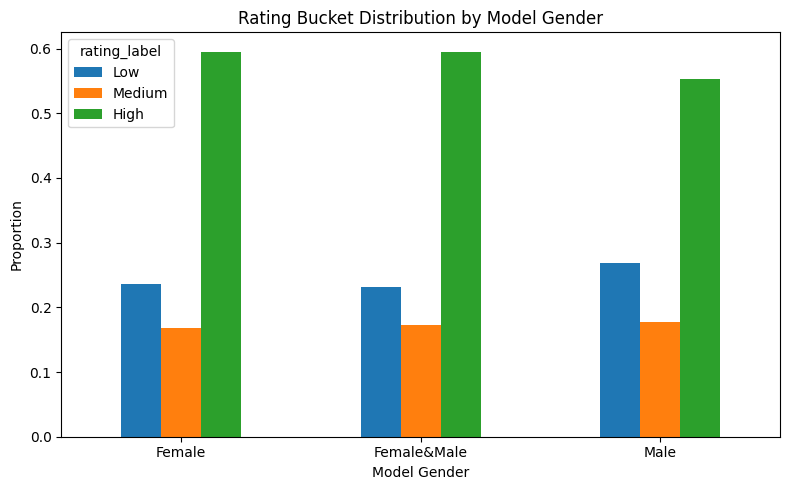

In [10]:
pm_summary = pd.crosstab(df_pm["model_attr"], df_pm["rating_label"], normalize="index")
print(pm_summary)

pm_summary.plot(kind="bar", figsize=(8,5))
plt.title("Rating Bucket Distribution by Model Gender")
plt.xlabel("Model Gender")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Deeper RQ1 Relationship Analysis: Rating Outcomes by Model Gender

The FP-Growth rules show which item combinations appear together, but rules alone can be misleading because high-support groups may dominate the results. To make the relationship clearer, this section compares each model-gender group against the overall baseline rating behavior. I use both raw proportions and lift-style ratios so the findings are easier to interpret.


In [11]:
# Relationship table: model gender vs rating bucket outcomes
relationship_table = (
    df_pm.groupby("model_attr")
    .agg(
        n_reviews=("rating", "size"),
        mean_rating=("rating", "mean"),
        high_rate=("rating_label", lambda s: (s == "High").mean()),
        medium_rate=("rating_label", lambda s: (s == "Medium").mean()),
        low_rate=("rating_label", lambda s: (s == "Low").mean()),
    )
    .sort_values("mean_rating", ascending=False)
)

overall_high_rate = (df_pm["rating_label"] == "High").mean()
overall_low_rate = (df_pm["rating_label"] == "Low").mean()
relationship_table["high_lift_vs_dataset"] = relationship_table["high_rate"] / overall_high_rate
relationship_table["low_lift_vs_dataset"] = relationship_table["low_rate"] / overall_low_rate

print("Overall high-rating rate:", round(overall_high_rate, 4))
print("Overall low-rating rate:", round(overall_low_rate, 4))
display(relationship_table.round(4))


Overall high-rating rate: 0.5821
Overall low-rating rate: 0.245


,n_reviews,mean_rating,high_rate,medium_rate,low_rate,high_lift_vs_dataset,low_lift_vs_dataset
model_attr,,,,,,,
Female&Male,93607,4.1075,0.5945,0.1734,0.2320,1.0214,0.947
Female,102513,4.0906,0.5954,0.1679,0.2367,1.0230,0.966
Male,89852,3.9976,0.5538,0.1781,0.2681,0.9515,1.094


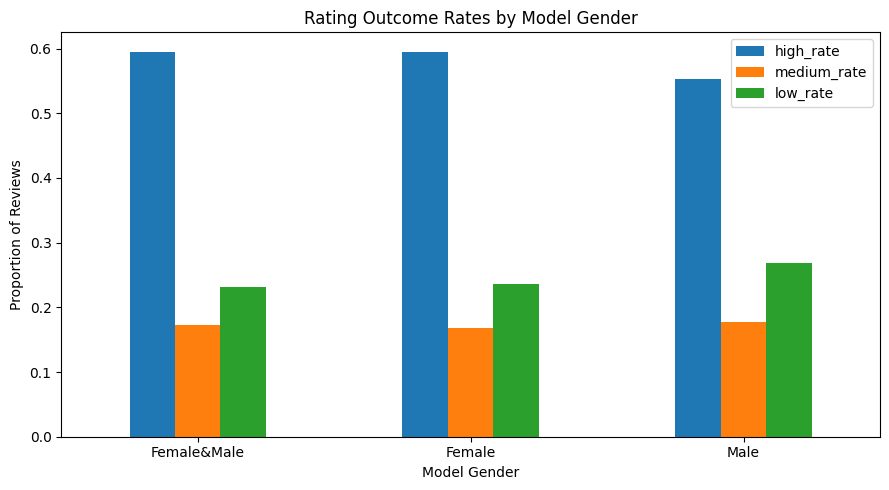

In [12]:
# Visualize the high/low outcome relationship in one place
plot_cols = ["high_rate", "medium_rate", "low_rate"]
relationship_table[plot_cols].plot(kind="bar", figsize=(9, 5))
plt.title("Rating Outcome Rates by Model Gender")
plt.xlabel("Model Gender")
plt.ylabel("Proportion of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Category-Level Relationship Check

A major risk in this project is confusing a gender relationship with a category relationship. For example, if one model-gender group appears more often in categories that already tend to receive higher ratings, the raw gender gap could be misleading. The next table checks the gender-rating relationship separately within product categories and highlights where the largest differences appear.


In [13]:
# Category-level model gender gaps
cat_gender_summary = (
    df_pm.groupby(["category", "model_attr"])
    .agg(
        n_reviews=("rating", "size"),
        mean_rating=("rating", "mean"),
        high_rate=("rating_label", lambda s: (s == "High").mean()),
        low_rate=("rating_label", lambda s: (s == "Low").mean()),
    )
    .reset_index()
)

# Only keep category/gender cells with enough observations to avoid unstable comparisons
min_cell_size = 50
cat_gender_summary = cat_gender_summary[cat_gender_summary["n_reviews"] >= min_cell_size].copy()

mean_pivot = cat_gender_summary.pivot(index="category", columns="model_attr", values="mean_rating")
high_pivot = cat_gender_summary.pivot(index="category", columns="model_attr", values="high_rate")

# Compute interpretable gaps where both groups are present
for comparison, left, right in [
    ("Female_minus_Male", "Female", "Male"),
    ("Female&Male_minus_Male", "Female&Male", "Male"),
]:
    if left in mean_pivot.columns and right in mean_pivot.columns:
        mean_pivot[comparison] = mean_pivot[left] - mean_pivot[right]
    if left in high_pivot.columns and right in high_pivot.columns:
        high_pivot[comparison] = high_pivot[left] - high_pivot[right]

print("Largest category-level mean rating gaps:")
display(mean_pivot.filter(like="minus").dropna(how="all").sort_values(
    by=mean_pivot.filter(like="minus").columns.tolist()[0],
    key=lambda s: s.abs(),
    ascending=False
).head(10).round(4))

print("Largest category-level high-rating-rate gaps:")
display(high_pivot.filter(like="minus").dropna(how="all").sort_values(
    by=high_pivot.filter(like="minus").columns.tolist()[0],
    key=lambda s: s.abs(),
    ascending=False
).head(10).round(4))


Largest category-level mean rating gaps:


model_attr,Female_minus_Male,Female&Male_minus_Male
category,,
Accessories & Supplies,1.0317,1.1432
Television & Video,-0.5730,-0.1520
Portable Audio & Video,-0.2314,-0.0156
Home Audio,-0.2257,0.1622
Computers & Accessories,0.1753,0.4329
Camera & Photo,-0.1408,-0.1456
Car Electronics & GPS,0.0327,0.4568
Headphones,-0.0152,0.0529


Largest category-level high-rating-rate gaps:


model_attr,Female_minus_Male,Female&Male_minus_Male
category,,
Accessories & Supplies,0.3131,0.3506
Television & Video,-0.1583,-0.0504
Portable Audio & Video,-0.1172,-0.0195
Computers & Accessories,0.0850,0.1748
Home Audio,-0.0568,0.0363
Camera & Photo,-0.0323,-0.0267
Car Electronics & GPS,-0.0251,0.0802
Headphones,0.0118,0.0219


### Category-Level Interpretation

The category-level tables make the result more nuanced. Some categories show Female or Female&Male products rated higher than Male products, but other categories show smaller or even negative gaps. This supports the project’s main interpretation: the relationship between model gender and rating is real enough to measure, but it is not uniform across every category. Category context matters, so the analysis should avoid saying that one model-gender group always performs better across the whole marketplace.


### FP-Growth Sensitivity Check

The number and type of patterns found by FP-Growth depends heavily on the minimum support threshold. This directly connects to the project write-up: lower support finds more specific patterns, but it can also introduce noisier or less reliable rules. Higher support gives fewer, broader rules that are easier to trust but may miss smaller subgroup effects.


,min_support,n_itemsets,n_rating_rules,n_gender_rating_rules,max_lift_gender_rating_rule
0,0.005,509,749,330,39.748277
1,0.010,327,375,156,14.968470
2,0.020,166,115,53,7.504071
3,0.050,49,24,11,1.679349


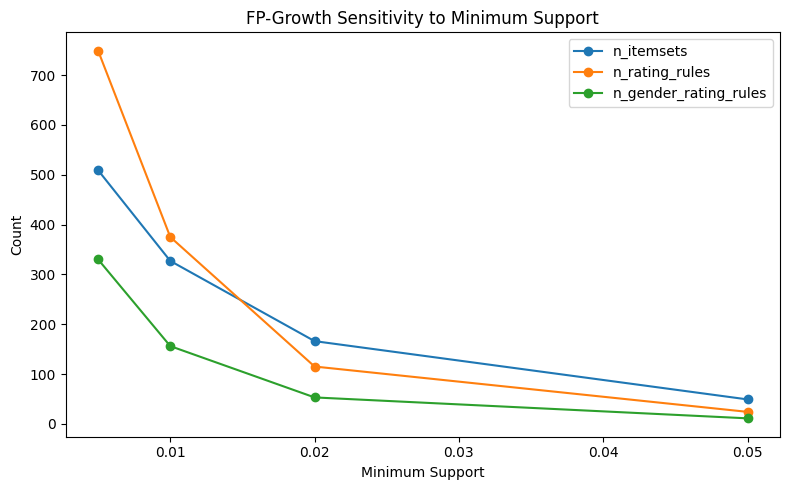

In [14]:
# Sensitivity analysis for support threshold choices
support_values = [0.005, 0.01, 0.02, 0.05]
sensitivity_rows = []

for support in support_values:
    freq_tmp = fpgrowth(df_trans, min_support=support, use_colnames=True)
    if len(freq_tmp) == 0:
        sensitivity_rows.append({
            "min_support": support,
            "n_itemsets": 0,
            "n_rating_rules": 0,
            "n_gender_rating_rules": 0,
            "max_lift_gender_rating_rule": np.nan,
        })
        continue

    rules_tmp = association_rules(freq_tmp, metric="lift", min_threshold=1.0)
    rating_rules_tmp = rules_tmp[
        rules_tmp["consequents"].apply(lambda x: any(label in x for label in ["High", "Medium", "Low"]))
    ].copy()
    gender_rating_rules_tmp = rating_rules_tmp[
        rating_rules_tmp["antecedents"].apply(lambda x: any(g in x for g in ["Male", "Female", "Female&Male"]))
    ].copy()
    sensitivity_rows.append({
        "min_support": support,
        "n_itemsets": len(freq_tmp),
        "n_rating_rules": len(rating_rules_tmp),
        "n_gender_rating_rules": len(gender_rating_rules_tmp),
        "max_lift_gender_rating_rule": gender_rating_rules_tmp["lift"].max() if len(gender_rating_rules_tmp) else np.nan,
    })

support_sensitivity = pd.DataFrame(sensitivity_rows)
display(support_sensitivity)

support_sensitivity.plot(x="min_support", y=["n_itemsets", "n_rating_rules", "n_gender_rating_rules"], marker="o", figsize=(8, 5))
plt.title("FP-Growth Sensitivity to Minimum Support")
plt.xlabel("Minimum Support")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Pattern Mining Results

The FP-Growth results align with the project question, but they should be interpreted as **context-dependent associations**, not proof that model gender alone determines ratings. The clearest raw pattern is that male-presented products have a lower high-rating rate and a higher low-rating rate than the female and mixed-gender groups in this filtered pattern-mining sample. Specifically, the crosstab shows Male products with about **55.4% High** and **26.8% Low**, compared with Female and Female&Male products at about **59.5% High** and **23–24% Low**.

The association rules deepen this finding by showing that model gender often appears together with specific brands and categories. This matters because some rules that appear to involve gender may actually be driven by a strong brand/category context. The support sensitivity check also supports the interpretation from the write-up: lowering `min_support` produces many more rules, including more specific subgroup patterns, while higher support thresholds produce fewer and broader rules that are easier to trust but less detailed.

Overall, RQ1 provides evidence of a relationship between model gender and rating outcomes, but the relationship is best described as **conditional on product context** rather than universal across all electronics products.


### RQ1 Interpretation

The most important pattern-mining takeaway is that gender-related rules should be interpreted contextually. A frequent itemset can be misleading if it appears to suggest a gender effect but is actually driven by a dominant brand or category. Because of this, I compare support, confidence, and lift rather than relying on raw frequency alone. As support thresholds become stricter, the number of discovered patterns drops, but the remaining rules become easier to interpret and less noisy.


## RQ2: Product Clustering

For RQ2, I cluster products using category, brand, model gender, and rating. Categorical fields are one-hot encoded and rating is standardized. I evaluate cluster quality with silhouette score and then inspect rating means, model-gender distributions, category distributions, and top brands within each cluster.


In [15]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

df_cl = df[["category", "brand", "model_attr", "rating"]].dropna().copy()

# Keep top brands for a cleaner clustering space
top_brands = df_cl["brand"].value_counts().head(25).index
df_cl = df_cl[df_cl["brand"].isin(top_brands)].copy()

# Sample for speed
sample_n = min(15000, len(df_cl))
df_cl = df_cl.sample(n=sample_n, random_state=42).copy()

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = encoder.fit_transform(df_cl[["category", "brand", "model_attr"]])

scaler = StandardScaler()
X_num = scaler.fit_transform(df_cl[["rating"]])

X = np.hstack([X_cat, X_num])

print(X.shape)

(15000, 39)


   k  silhouette
0  2    0.270648
1  3    0.175932
2  4    0.218731
3  5    0.217236
4  6    0.221019
5  7    0.216608
6  8    0.189726


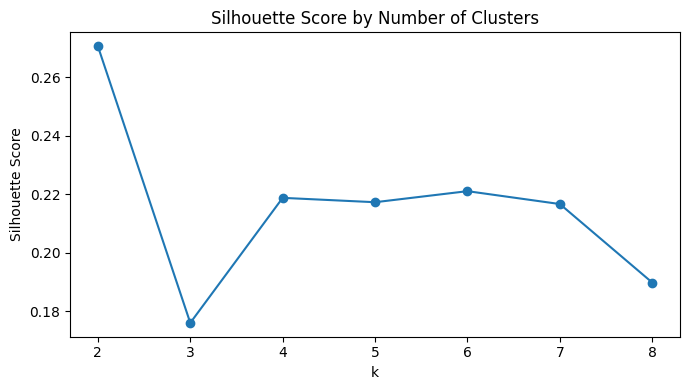

In [16]:
sil_scores = []
k_values = range(2, 9)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    sil_scores.append((k, sil))

sil_df = pd.DataFrame(sil_scores, columns=["k", "silhouette"])
print(sil_df)

plt.figure(figsize=(7,4))
plt.plot(sil_df["k"], sil_df["silhouette"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

In [17]:
best_k = 2

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_cl["cluster"] = kmeans.fit_predict(X)

print("Final silhouette:", silhouette_score(X, df_cl["cluster"]))

Final silhouette: 0.27064832877464967


In [18]:
print(df_cl["cluster"].value_counts().sort_index())

cluster
0    11253
1     3747
Name: count, dtype: int64


cluster
1    1.886042
0    4.771972
Name: rating, dtype: float64


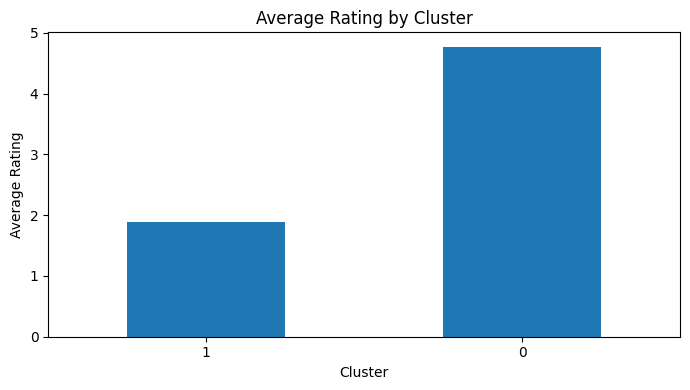

In [19]:
cluster_rating = df_cl.groupby("cluster")["rating"].mean().sort_values()
print(cluster_rating)

cluster_rating.plot(kind="bar", figsize=(7,4))
plt.title("Average Rating by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

model_attr    Female  Female&Male      Male
cluster                                    
0           0.356172     0.326402  0.317426
1           0.345610     0.307179  0.347211


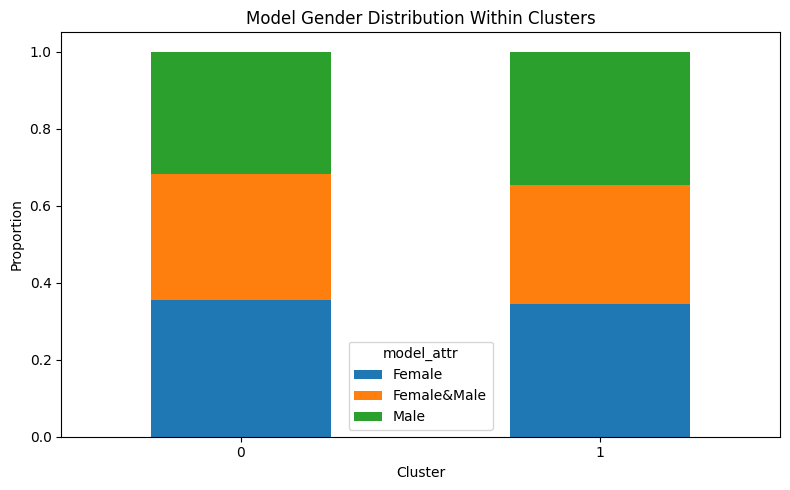

In [20]:
cluster_gender = pd.crosstab(df_cl["cluster"], df_cl["model_attr"], normalize="index")
print(cluster_gender)

cluster_gender.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Model Gender Distribution Within Clusters")
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
cluster_category = pd.crosstab(df_cl["cluster"], df_cl["category"], normalize="index")
print(cluster_category.round(3))

category  Accessories & Supplies  Camera & Photo  Car Electronics & GPS  \
cluster                                                                   
0                          0.058           0.209                  0.032   
1                          0.050           0.189                  0.029   

category  Computers & Accessories  Headphones  Home Audio  \
cluster                                                     
0                           0.205       0.367       0.036   
1                           0.177       0.428       0.044   

category  Portable Audio & Video  Security & Surveillance  Television & Video  \
cluster                                                                         
0                          0.065                    0.000               0.026   
1                          0.057                    0.001               0.022   

category  Wearable Technology  
cluster                        
0                       0.002  
1                       0.003  


In [22]:
for c in sorted(df_cl["cluster"].unique()):
    print(f"\nTop brands in cluster {c}:")
    print(df_cl[df_cl["cluster"] == c]["brand"].value_counts().head(10))


Top brands in cluster 0:
brand
Bose          1266
Logitech      1164
Sony           832
Mpow           680
EldHus         678
Fujifilm       575
Sennheiser     513
Etre Jeune     484
TaoTronics     477
Pyle           367
Name: count, dtype: int64

Top brands in cluster 1:
brand
Logitech      341
Bose          335
Mpow          240
JLAB          217
Sony          217
Pyle          213
Skullcandy    204
EldHus        182
Linksys       174
Sennheiser    170
Name: count, dtype: int64


In [23]:
# Without model_attr
X_cat_no_gender = encoder.fit_transform(df_cl[["category", "brand"]])
X_no_gender = np.hstack([X_cat_no_gender, X_num])

sil_scores_no_gender = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_no_gender)
    sil = silhouette_score(X_no_gender, labels)
    sil_scores_no_gender.append((k, sil))

sil_no_gender_df = pd.DataFrame(sil_scores_no_gender, columns=["k", "silhouette_no_gender"])
compare_sil = sil_df.merge(sil_no_gender_df, on="k")
print(compare_sil)

   k  silhouette  silhouette_no_gender
0  2    0.270648              0.323101
1  3    0.175932              0.194684
2  4    0.218731              0.251887
3  5    0.217236              0.228506
4  6    0.221019              0.239765
5  7    0.216608              0.230796
6  8    0.189726              0.268531


### Deeper RQ2 Cluster Interpretation

The clustering section should not only report that clusters exist; it should explain what makes each cluster different. The profile below summarizes each cluster by size, average rating, model-gender mix, and dominant product categories/brands. This makes the cluster results easier to connect back to the project question.


In [24]:
# Compact cluster profiles
cluster_profiles = []
for cluster_id, part in df_cl.groupby("cluster"):
    top_gender = part["model_attr"].value_counts(normalize=True).head(3)
    top_categories = part["category"].value_counts(normalize=True).head(3)
    top_brands = part["brand"].value_counts(normalize=True).head(3)
    cluster_profiles.append({
        "cluster": cluster_id,
        "n_reviews": len(part),
        "mean_rating": part["rating"].mean(),
        "top_model_gender_mix": "; ".join([f"{idx}: {val:.1%}" for idx, val in top_gender.items()]),
        "top_categories": "; ".join([f"{idx}: {val:.1%}" for idx, val in top_categories.items()]),
        "top_brands": "; ".join([f"{idx}: {val:.1%}" for idx, val in top_brands.items()]),
    })

cluster_profiles_df = pd.DataFrame(cluster_profiles).sort_values("cluster")
display(cluster_profiles_df)


,cluster,n_reviews,mean_rating,top_model_gender_mix,top_categories,top_brands
0,0,11253,4.771972,Female: 35.6%; Female&Male: 32.6%; Male: 31.7%,Headphones: 36.7%; Camera & Photo: 20.9%; Comp...,Bose: 11.3%; Logitech: 10.3%; Sony: 7.4%
1,1,3747,1.886042,Male: 34.7%; Female: 34.6%; Female&Male: 30.7%,Headphones: 42.8%; Camera & Photo: 18.9%; Comp...,Logitech: 9.1%; Bose: 8.9%; Mpow: 6.4%


In [25]:
# Compare whether clusters separate rating behavior beyond model gender alone
cluster_gender_rating = (
    df_cl.groupby(["cluster", "model_attr"])
    .agg(n_reviews=("rating", "size"), mean_rating=("rating", "mean"))
    .reset_index()
    .sort_values(["cluster", "mean_rating"], ascending=[True, False])
)

display(cluster_gender_rating.round(4))


,cluster,model_attr,n_reviews,mean_rating
1,0,Female&Male,3673,4.7800
0,0,Female,4008,4.7799
2,0,Male,3572,4.7548
5,1,Male,1301,1.9093
4,1,Female&Male,1151,1.8992
3,1,Female,1295,1.8510


# Clustering Results

The clustering results mostly separate reviews by **rating level**, not by model gender. With the selected features, the best silhouette score occurs at `k = 2`, and the two clusters have very different average ratings: one cluster is strongly high-rated while the other is strongly low-rated. This means the clustering is useful for identifying broad review-quality segments.

However, the model-gender distributions inside the clusters are fairly similar. The high-rated cluster is approximately balanced across Female, Female&Male, and Male products, while the low-rated cluster has only a slightly larger Male share. The comparison where model gender is removed also shows that clustering quality does not improve from including gender; in fact, the silhouette scores are generally higher without the gender features. 

So RQ2 aligns with the broader conclusion: model gender is related to ratings, but it is **not the main structural feature** that defines the natural clusters. Rating, category, and brand context explain the cluster structure more strongly.


### RQ2 Interpretation

The clustering results are useful mostly as a contrast to RQ1 and RQ3. The clusters separate high-rated and lower-rated products more clearly than they separate gender groups. This suggests that model gender is not the main structural axis of the dataset, even though it still appears in association rules and regression results.


## RQ3: Controlled Regression and Fairness-Oriented Analysis

For RQ3, I estimate the relationship between model gender and rating while controlling for category and brand. The baseline group is `Male`, so the coefficients for `Female` and `Female&Male` can be read as average rating differences relative to male-presented products, after accounting for observable product category and brand differences.

This is not a full randomized causal experiment, so I avoid claiming absolute causality. Instead, I interpret the results as evidence of a controlled association that remains after including major product controls.


In [26]:
import statsmodels.formula.api as smf

df_ca = df[["rating", "model_attr", "category", "brand"]].dropna().copy()

# Keep top brands for stability and interpretability
top_brands = df_ca["brand"].value_counts().head(50).index
df_ca = df_ca[df_ca["brand"].isin(top_brands)].copy()

# Set Male as reference group
df_ca["model_attr"] = pd.Categorical(
    df_ca["model_attr"],
    categories=["Male", "Female", "Female&Male"],
    ordered=False
)

print(df_ca.shape)
print(df_ca["model_attr"].value_counts())

(331120, 4)
model_attr
Female         116258
Female&Male    109528
Male           105334
Name: count, dtype: int64


In [27]:
ols_model = smf.ols(
    "rating ~ C(model_attr, Treatment(reference='Male')) + C(category) + C(brand)",
    data=df_ca
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     243.6
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        03:19:41   Log-Likelihood:            -5.6620e+05
No. Observations:              331120   AIC:                         1.133e+06
Df Residuals:                  331059   BIC:                         1.133e+06
Df Model:                          60                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [28]:
coef_table = ols_model.summary2().tables[1]

rows_of_interest = [
    "C(model_attr, Treatment(reference='Male'))[T.Female]",
    "C(model_attr, Treatment(reference='Male'))[T.Female&Male]"
]

print(coef_table.loc[rows_of_interest, ["Coef.", "Std.Err.", "t", "P>|t|", "[0.025", "0.975]"]])

                                                       Coef.  Std.Err.  \
C(model_attr, Treatment(reference='Male'))[T.Fe...  0.083158  0.006961   
C(model_attr, Treatment(reference='Male'))[T.Fe...  0.135033  0.007265   

                                                            t         P>|t|  \
C(model_attr, Treatment(reference='Male'))[T.Fe...  11.945505  6.960931e-33   
C(model_attr, Treatment(reference='Male'))[T.Fe...  18.586127  4.556218e-77   

                                                      [0.025    0.975]  
C(model_attr, Treatment(reference='Male'))[T.Fe...  0.069514  0.096802  
C(model_attr, Treatment(reference='Male'))[T.Fe...  0.120793  0.149273  


In [29]:
raw_means = df_ca.groupby("model_attr")["rating"].mean()

raw_gap_female = raw_means["Female"] - raw_means["Male"]
raw_gap_both = raw_means["Female&Male"] - raw_means["Male"]

controlled_female = coef_table.loc[
    "C(model_attr, Treatment(reference='Male'))[T.Female]", "Coef."
]
controlled_both = coef_table.loc[
    "C(model_attr, Treatment(reference='Male'))[T.Female&Male]", "Coef."
]

print(f"Raw Female - Male gap: {raw_gap_female:.4f}")
print(f"Raw Female&Male - Male gap: {raw_gap_both:.4f}")
print(f"Controlled Female - Male effect: {controlled_female:.4f}")
print(f"Controlled Female&Male - Male effect: {controlled_both:.4f}")

Raw Female - Male gap: 0.1082
Raw Female&Male - Male gap: 0.1226
Controlled Female - Male effect: 0.0832
Controlled Female&Male - Male effect: 0.1350


In [30]:
df_log = df_ca.copy()
df_log["high_rating"] = (df_log["rating"] >= 5).astype(int)

logit_model = smf.logit(
    "high_rating ~ C(model_attr, Treatment(reference='Male')) + C(category) + C(brand)",
    data=df_log
).fit(maxiter=200)

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.663017
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            high_rating   No. Observations:               331120
Model:                          Logit   Df Residuals:                   331059
Method:                           MLE   Df Model:                           60
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                 0.02631
Time:                        03:19:51   Log-Likelihood:            -2.1954e+05
converged:                       True   LL-Null:                   -2.2547e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------
Intercept     

In [31]:
logit_params = logit_model.params
odds_ratios = np.exp(logit_params)

or_rows = [
    "C(model_attr, Treatment(reference='Male'))[T.Female]",
    "C(model_attr, Treatment(reference='Male'))[T.Female&Male]"
]

print("Odds Ratios for 5-star outcome:")
print(odds_ratios.loc[or_rows])

Odds Ratios for 5-star outcome:
C(model_attr, Treatment(reference='Male'))[T.Female]         1.105622
C(model_attr, Treatment(reference='Male'))[T.Female&Male]    1.173692
dtype: float64


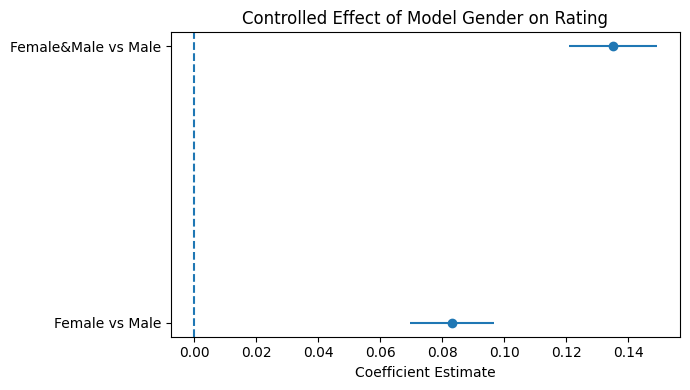

In [32]:
coef_plot = coef_table.loc[rows_of_interest, ["Coef.", "[0.025", "0.975]"]].copy()
coef_plot["label"] = ["Female vs Male", "Female&Male vs Male"]

plt.figure(figsize=(7,4))
plt.errorbar(
    coef_plot["Coef."],
    coef_plot["label"],
    xerr=[
        coef_plot["Coef."] - coef_plot["[0.025"],
        coef_plot["0.975]"] - coef_plot["Coef."]
    ],
    fmt="o"
)
plt.axvline(0, linestyle="--")
plt.title("Controlled Effect of Model Gender on Rating")
plt.xlabel("Coefficient Estimate")
plt.tight_layout()
plt.show()

### Deeper RQ3: Interaction Analysis

The controlled regression estimates the average relationship between model gender and rating after accounting for product category and brand. However, an average effect can hide category-specific differences. This interaction model asks whether the gender-rating relationship changes across categories. If interaction terms are large or significant, it suggests the relationship is not uniform across the marketplace.


In [33]:
# Interaction model: does the model-gender relationship vary by category?
interaction_model = smf.ols(
    "rating ~ C(model_attr, Treatment(reference='Male')) * C(category) + C(brand)",
    data=df_ca
).fit()

interaction_terms = interaction_model.summary2().tables[1]
interaction_terms = interaction_terms[interaction_terms.index.str.contains(":C\(category\)", regex=True)].copy()
interaction_terms["abs_coef"] = interaction_terms["Coef."].abs()

print("Largest model-gender by category interaction terms:")
display(interaction_terms.sort_values("abs_coef", ascending=False)[["Coef.", "Std.Err.", "P>|t|", "[0.025", "0.975]"]].head(15).round(4))


Largest model-gender by category interaction terms:


,Coef.,Std.Err.,P>|t|,[0.025,0.975]
"C(model_attr, Treatment(reference='Male'))[T.Female]:C(category)[T.Security & Surveillance]",-1.1290,0.1520,0.0000,-1.4268,-0.8311
"C(model_attr, Treatment(reference='Male'))[T.Female]:C(category)[T.Home Audio]",-0.9906,0.0585,0.0000,-1.1052,-0.8760
"C(model_attr, Treatment(reference='Male'))[T.Female&Male]:C(category)[T.Home Audio]",-0.7348,0.0567,0.0000,-0.8460,-0.6237
"C(model_attr, Treatment(reference='Male'))[T.Female&Male]:C(category)[T.Camera & Photo]",-0.7285,0.0409,0.0000,-0.8086,-0.6484
"C(model_attr, Treatment(reference='Male'))[T.Female]:C(category)[T.Portable Audio & Video]",-0.6262,0.0438,0.0000,-0.7121,-0.5404
"C(model_attr, Treatment(reference='Male'))[T.Female&Male]:C(category)[T.Television & Video]",-0.6121,0.0543,0.0000,-0.7186,-0.5056
"C(model_attr, Treatment(reference='Male'))[T.Female&Male]:C(category)[T.Portable Audio & Video]",-0.5892,0.0429,0.0000,-0.6733,-0.5050
"C(model_attr, Treatment(reference='Male'))[T.Female&Male]:C(category)[T.Headphones]",-0.5505,0.0387,0.0000,-0.6262,-0.4747
"C(model_attr, Treatment(reference='Male'))[T.Female]:C(category)[T.Headphones]",-0.5425,0.0366,0.0000,-0.6141,-0.4708
"C(model_attr, Treatment(reference='Male'))[T.Female]:C(category)[T.Television & Video]",-0.5380,0.0615,0.0000,-0.6585,-0.4174


### Practical Significance Check

Statistical significance can be misleading in large datasets because even tiny effects may become significant. This section compares raw and controlled gaps to the full 1–5 rating scale, so the conclusion discusses practical size, not just p-values.


In [34]:
# Practical effect size relative to the 1-5 star scale
rating_scale_width = df_ca["rating"].max() - df_ca["rating"].min()
effect_size_summary = pd.DataFrame({
    "comparison": ["Female - Male", "Female&Male - Male"],
    "raw_gap_stars": [raw_gap_female, raw_gap_both],
    "controlled_gap_stars": [controlled_female, controlled_both],
})
effect_size_summary["controlled_gap_pct_of_scale"] = (
    effect_size_summary["controlled_gap_stars"].abs() / rating_scale_width * 100
)

display(effect_size_summary.round(4))


,comparison,raw_gap_stars,controlled_gap_stars,controlled_gap_pct_of_scale
0,Female - Male,0.1082,0.0832,2.0789
1,Female&Male - Male,0.1226,0.1350,3.3758


# Controlled Association / Fairness Analysis Results

The regression results align with the pattern-mining findings, but the language should stay careful: this is evidence of a **controlled association**, not a randomized causal effect. After controlling for product category and brand, Female-presented products are associated with an average rating increase of about **0.083 stars** relative to Male-presented products, and Female&Male products are associated with an average increase of about **0.135 stars**. Both estimates are statistically significant, but their practical size is modest on a 1–5 star scale.

The logistic regression gives a similar story for 5-star outcomes. Female-presented products have about **10.6% higher odds** of receiving a 5-star rating than Male-presented products, while Female&Male products have about **17.4% higher odds**, after the same controls. This supports the claim that the gender-rating relationship does not disappear after accounting for major observable product differences.

The interaction analysis adds an important caveat: the relationship is not uniform across every product category. Some category-specific interaction terms are large, which means the model-gender relationship changes depending on product type. Therefore, the strongest conclusion is that model gender has a measurable and systematic **association** with ratings, but that association is context-dependent and should not be overstated as direct causation.


## Final Takeaways

This notebook examines whether model-gender presentation in Amazon Electronics reviews is related to rating outcomes. The analysis uses three complementary views:

1. **Pattern mining / FP-Growth** identifies recurring product, brand, category, model-gender, and rating combinations. The results show that Female and Female&Male products are more associated with high-rating outcomes, while Male products appear more often in low-rating contexts. However, many rules also include brand and category, so the relationship should be interpreted as contextual rather than gender-only.
2. **Clustering** checks whether reviews naturally group into segments with different rating behavior and model-gender composition. The clusters mainly separate high-rated and low-rated products. Model gender appears inside the clusters, but it does not define the clusters by itself.
3. **Controlled regression** compares raw rating gaps against estimates that account for category and brand. The controlled results still show positive Female and Female&Male associations relative to Male, which supports the existence of a measurable relationship after major observable controls.

The final conclusion is that model gender is associated with product ratings in the Electronics dataset, but the relationship is **subtle, context-dependent, and not enough by itself to claim direct causal bias**. The strongest evidence comes from the consistency across methods: pattern mining shows gender-linked rating rules, clustering shows gender is not the main structural driver, and regression shows that the rating gap remains even after controlling for category and brand.


# **On my honor, I declare the following resources:**
1. Collaborators:
-

2. Web Sources:
- Homework 1 & 2 for EDA inspiration
- https://www.icwsm.org/2025/schedule/allpapers.html
- https://kdd2025.kdd.org/datasets-and-benchmarks-track-papers-2/
- https://pandas.pydata.org/?utm_source=chatgpt.com – for data cleaning and transformation
- https://scikit-learn.org/?utm_source=chatgpt.com – for clustering, preprocessing, and evaluation metrics
- https://www.statsmodels.org/?utm_source=chatgpt.com – for OLS regression setup and interpretation
- https://seaborn.pydata.org/?utm_source=chatgpt.com – for exploratory data analysis and plotting
- https://matplotlib.org/?utm_source=chatgpt.com – for visualizations used during EDA


3. AI Tools:
- chatGPT: Used to compare the three datasets for the Comparative Analysis of Datasets
- chatGPT: Used to help generate a EDA
- chatGPT: Provided with EDA results and asked to give observations, hypothesis, and potential RQs
- chatGPT: Used to debug code errors (e.g., OneHotEncoder parameter issues, model setup)

- chatGPT: Used to explain clustering evaluation metrics (e.g., silhouette score)

- chatGPT: Used to refine explanations of algorithmic decisions and interpretations

- chatGPT: Used to structure and polish written responses for clarity


## Environment Export

Run the cell below in Colab to export the exact package versions from your session.

```python
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')
!python --version
```
